detecting spikes, noise and drift for

1. EDA
2. TEMP

In [10]:
import pickle

with open("../data/raw/WESAD/S2/S2.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

In [11]:
# Wrist
wrist_eda = data['signal']['wrist']['EDA'].flatten()
wrist_temp = data['signal']['wrist']['TEMP'].flatten()

# Chest
chest_eda = data['signal']['chest']['EDA'].flatten()
chest_temp = data['signal']['chest']['Temp'].flatten()

In [12]:
# Cell 1: Detection Functions
import numpy as np
from scipy.stats import zscore
from scipy.stats import linregress

def detect_noise(signal, name="Signal"):

    diff_signal = np.diff(signal)

    noise_level = np.std(diff_signal)

    print(f"\n{name}")
    print("Noise Level (STD of first difference):", noise_level)

    return noise_level


def detect_spikes(signal, threshold=3, name="Signal"):

    z = np.abs(zscore(signal))

    spike_indices = np.where(z > threshold)[0]

    print(f"\n{name}")
    print("Number of spikes:", len(spike_indices))

    return spike_indices


def detect_drift(signal, name="Signal"):

    x = np.arange(len(signal))

    slope, intercept, r, p, std_err = linregress(x, signal)

    print(f"\n{name}")
    print("Drift Slope:", slope)

    return slope

In [14]:
# Cell 2: Wrist EDA
detect_noise(wrist_eda, "Wrist EDA")

spikes_wrist_eda = detect_spikes(
    wrist_eda,
    threshold=3,
    name="Wrist EDA"
)

detect_drift(wrist_eda, "Wrist EDA")


Wrist EDA
Noise Level (STD of first difference): 0.01886522909564867

Wrist EDA
Number of spikes: 139

Wrist EDA
Drift Slope: -1.8021900479117574e-05


np.float64(-1.8021900479117574e-05)

In [15]:
# Cell 3: Chest EDA
detect_noise(chest_eda, "Chest EDA")

spikes_chest_eda = detect_spikes(
    chest_eda,
    threshold=3,
    name="Chest EDA"
)

detect_drift(chest_eda, "Chest EDA")


Chest EDA
Noise Level (STD of first difference): 0.026198855703604192

Chest EDA
Number of spikes: 192777

Chest EDA
Drift Slope: -6.731387448146534e-07


np.float64(-6.731387448146534e-07)

In [16]:
# Cell 4: Wrist TEMP
detect_noise(wrist_temp, "Wrist TEMP")

spikes_wrist_temp = detect_spikes(
    wrist_temp,
    threshold=3,
    name="Wrist TEMP"
)

detect_drift(wrist_temp, "Wrist TEMP")


Wrist TEMP
Noise Level (STD of first difference): 0.009545593341909967

Wrist TEMP
Number of spikes: 0

Wrist TEMP
Drift Slope: -8.717338383682043e-05


np.float64(-8.717338383682043e-05)

In [17]:
# Cell 5: Chest TEMP
detect_noise(chest_temp, "Chest TEMP")

spikes_chest_temp = detect_spikes(
    chest_temp,
    threshold=3,
    name="Chest TEMP"
)

detect_drift(chest_temp, "Chest TEMP")


Chest TEMP
Noise Level (STD of first difference): 0.027947312

Chest TEMP
Number of spikes: 0

Chest TEMP
Drift Slope: 8.096850155874258e-07


np.float64(8.096850155874258e-07)

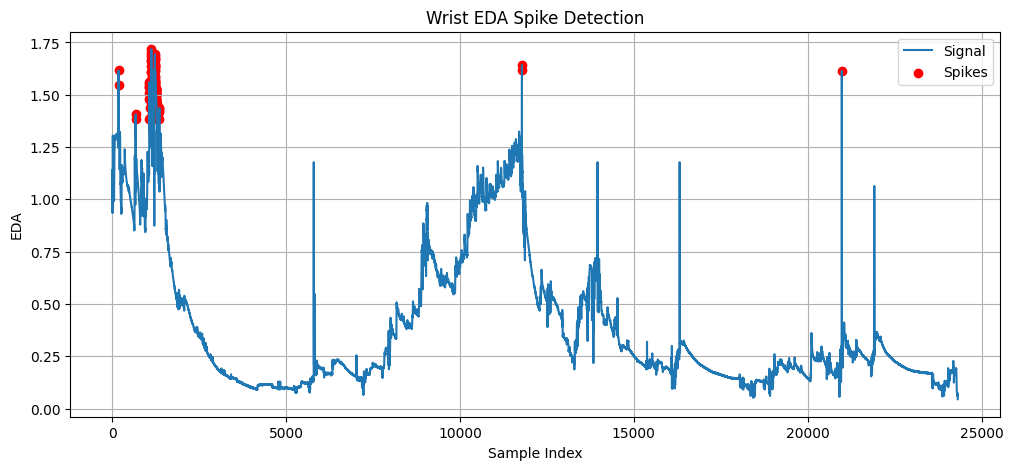

In [18]:
# Visualize Spikes

# For example, Wrist EDA:

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(wrist_eda, label="Signal")

plt.scatter(
    spikes_wrist_eda,
    wrist_eda[spikes_wrist_eda],
    color='red',
    label='Spikes'
)

plt.title("Wrist EDA Spike Detection")
plt.xlabel("Sample Index")
plt.ylabel("EDA")

plt.legend()
plt.grid()

plt.show()